# Federated Learning Model Evaluation & Data Analysis

This notebook evaluates BiSeNetV2 models trained under federated learning settings. It explores the relationship between client data heterogeneity (label skew) and federated aggregator performance (FedAvg, FedProx) across communication rounds.

### Structure:
1. **Configuration & Setup**: Import libraries and set paths.
2. **Data Distribution & Client Selection Analysis**: Analyzes selection frequencies and label skew (pixel distribution) per client.
3. **Model Evaluation**: Computes mIoU and F1-scores across all clients and rounds.
4. **Performance Visualization**: Heatmaps for overall client performance.
5. **Variance Analysis**: Evaluates performance heterogeneity trends across rounds.
6. **Per-Class Performance**: Identifies which specific classes suffer from label skew.
7. **Export Results**: Saves all data to CSV.

## Section 1: Configuration & Setup

In [3]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import torch
import torch.nn.functional as F
from tqdm import tqdm

# Add project root to path
sys.path.insert(0, '/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL/fl-cityscapes-bisenetv2/')

# Import from the project
from lib.models import BiSeNetV2
from lib.data import get_data_loader
import lib.data.transform_cv2 as T
from fl_cityscapes_bisenetv2.data_preparation.client_dataset import CityScapesClientDataset
from tools.eval_metrics import compute_metrics_from_cm

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================================================
# CONFIGURATION - Modify these paths according to your directory structure
# ============================================================================

PROJECT_ROOT = Path('/home/moustafa/Me/Projects/Grad/Code/BiseNet-FL')
RESULTS_ROOT = Path('/home/moustafa/Me/Projects/Grad/Experiments/Third_Trial')  # Adjust as needed
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'cityscapes'

PARTITION_ID = "IID_Partition"
PARTITION_CLIENTS = 2

# Data partition configuration
DATA_PARTITION_FILE = DATA_ROOT / 'iid_partitions.json'
NUM_CLASSES = 19  # Cityscapes has 19 semantic classes

# Cityscapes class names (moved up for global accessibility)
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence',
    'pole', 'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck',
    'bus', 'train', 'motorcycle', 'bicycle'
]

# Aggregators to evaluate
AGGREGATORS = ['FedAvg', 'FedProx']

# Device and Batch configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EVAL_BATCH_SIZE = 4
print(f"Using device: {DEVICE}")

Using device: cuda


## Section 2: Helper Functions

In [5]:
class MetricsCalculator:
    """Calculate semantic segmentation metrics from predictions and labels."""
    def __init__(self, n_classes, ignore_label=255):
        self.n_classes = n_classes
        self.ignore_label = ignore_label
        self.confusion_matrix = np.zeros((n_classes, n_classes))
    
    def update(self, predictions, labels):
        predictions = predictions.cpu().numpy() if isinstance(predictions, torch.Tensor) else predictions
        labels = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else labels
        predictions = predictions.flatten()
        labels = labels.flatten()
        mask = labels != self.ignore_label
        np.add.at(self.confusion_matrix, (labels[mask], predictions[mask]), 1)
    
    def compute_metrics(self) -> Dict[str, float]:
        return compute_metrics_from_cm(self.confusion_matrix)

def load_model(model_path: str, n_classes: int = 19, device: str = 'cuda') -> BiSeNetV2:
    model = BiSeNetV2(n_classes, aux_mode='eval')
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint, strict=False)
        print(f"✓ Model loaded from {model_path}")
    else:
        print(f"✗ Model path not found: {model_path}")
        return None
    model = model.to(device)
    model.eval()
    return model

def load_client_dataset(im_root, partition_file, partition_id, n_classes=19, batch_size=4):
    try:
        with open(partition_file, 'r', encoding='utf-8') as f:
            data_partitions = json.load(f)
        partition = data_partitions[str(partition_id)]
        ds = CityScapesClientDataset(im_root, partition["data"], T.TransformationVal())
        from torch.utils.data import DataLoader
        dataloader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
        return dataloader, len(ds)
    except Exception as e:
        print(f"Error loading client {partition_id} data: {e}")
        return None, 0

@torch.no_grad()
def evaluate_model_on_client(model, dataloader, n_classes=19, device='cuda', return_confusion_matrix=False):
    if model is None or dataloader is None:
        return None
    metrics_calc = MetricsCalculator(n_classes, ignore_label=255)
    model.eval()
    for images, labels in tqdm(dataloader, desc="Evaluating", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predictions = torch.argmax(outputs[0], dim=1)
        metrics_calc.update(predictions, labels.squeeze(1))
    
    metrics = metrics_calc.compute_metrics()
    if return_confusion_matrix:
        return metrics, metrics_calc.confusion_matrix
    return metrics

def compute_client_pixel_distribution(dataloader, n_classes=19, ignore_label=255):
    """Calculate pixel count per class for a client's dataset."""
    pixel_counts = np.zeros(n_classes, dtype=np.int64)
    for images, labels in tqdm(dataloader, desc="Counting pixels", leave=False):
        labels = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else labels
        mask = labels != ignore_label
        valid_labels = labels[mask]
        counts = np.bincount(valid_labels.flatten(), minlength=n_classes)
        pixel_counts += counts
    return pixel_counts

print("Helper functions defined successfully!")

Helper functions defined successfully!


## Section 3: Data Distribution & Client Selection Analysis (Plot 1)
This section analyzes the actual data distribution (pixel counts per class) for each client and compares actual selection frequencies against target probabilities. This helps contextualize later performance discrepancies.


ANALYZING CLIENT DATA DISTRIBUTION (PIXEL COUNTS HEATMAP)
Loading data for Client 0...


Loading data for Client 1...


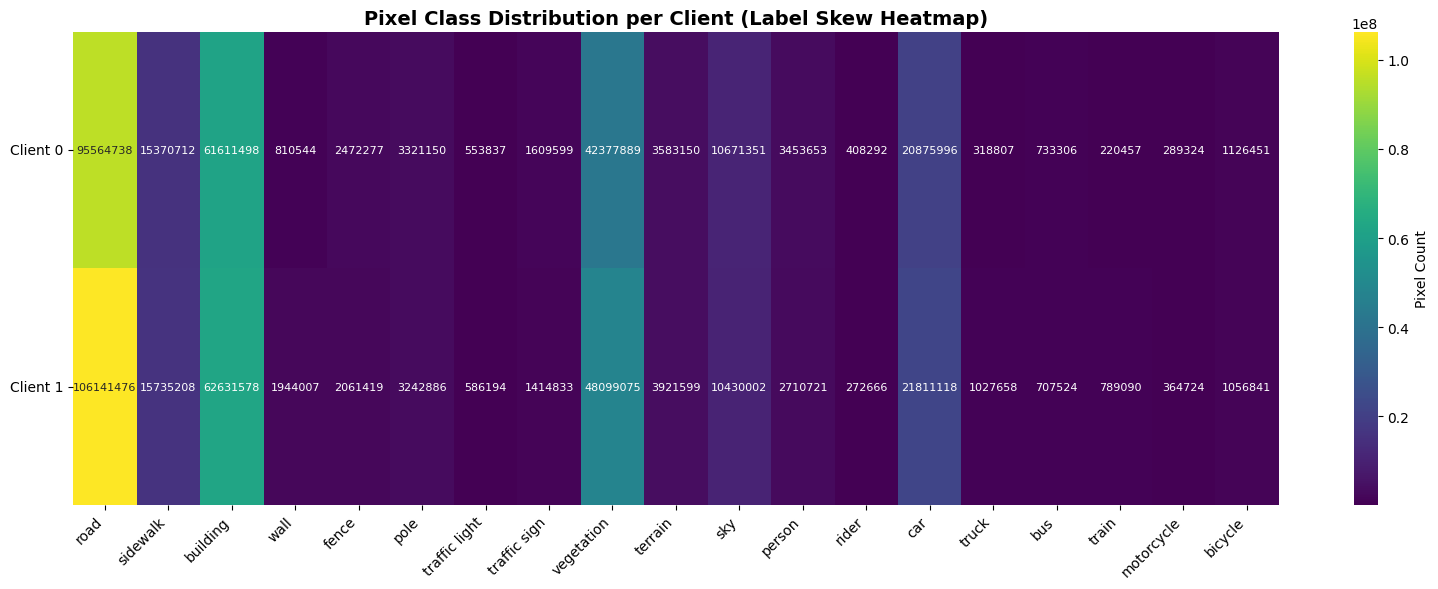

✓ Saved client pixel distribution heatmap to /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/client_pixel_distribution_heatmap.png


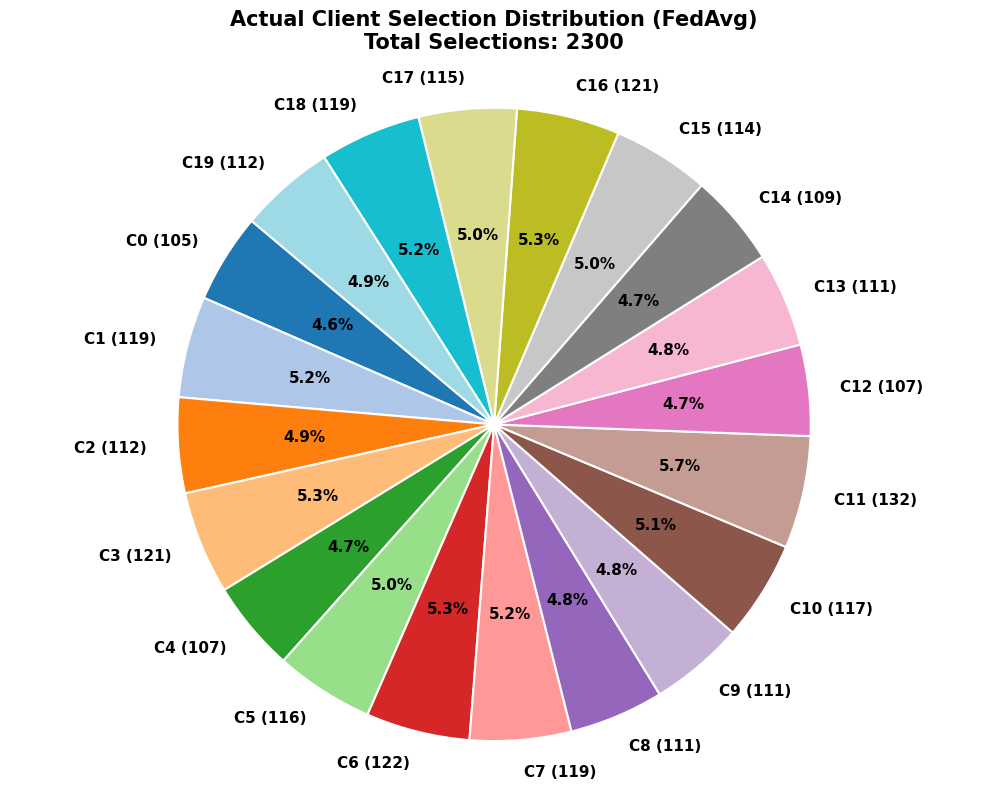

✓ Saved client selection pie chart to /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedAvg/client_selection_pie_FedAvg.png


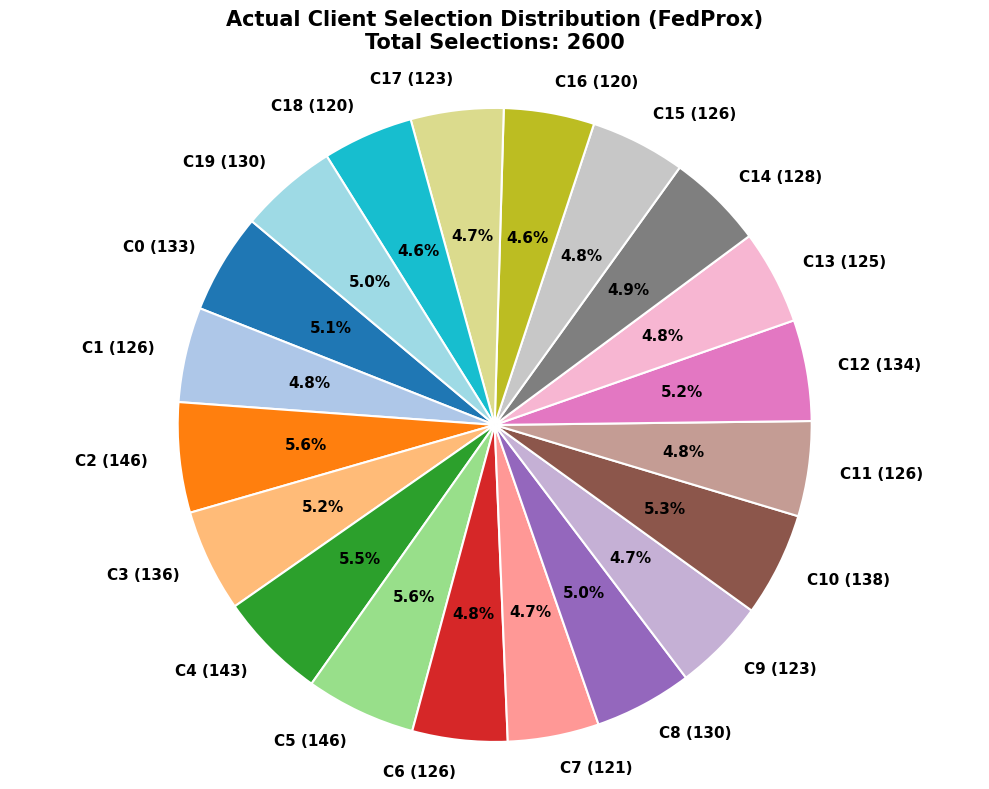

✓ Saved client selection pie chart to /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedProx/client_selection_pie_FedProx.png


In [6]:
def plot_client_selection_stats(aggregator: str, base_path: Path, output_dir: Path):
    """Plots actual client selection counts as a pie chart by aggregating round logs."""
    if not base_path.exists():
        print(f"Base path '{base_path}' not found for {aggregator}. Skipping analysis.")
        return

    selection_counts = {}
    total_selections = 0
    found_logs = False
    max_client_id = 0

    # Iterate through all round directories
    for round_dir in sorted([d for d in base_path.iterdir() if d.is_dir() and d.name.isdigit()], key=lambda x: int(x.name)):
        log_path = round_dir / 'client_selection_log.json'
        if log_path.exists():
            found_logs = True
            with open(log_path, 'r') as f:
                data = json.load(f)
            
            round_selections = []
            
            # Handle the specific dictionary format {"1": [...], "2": [...]}
            if isinstance(data, dict):
                for key, val in data.items():
                    if isinstance(val, list):
                        round_selections.extend(val)
            # Fallback for raw lists
            elif isinstance(data, list):
                round_selections = data

            # Process selections
            for client_id in round_selections:
                client_id_str = str(client_id)
                max_client_id = max(max_client_id, int(client_id))
                
                if client_id_str not in selection_counts:
                    selection_counts[client_id_str] = 0
                selection_counts[client_id_str] += 1
                total_selections += 1

    if not found_logs:
        print(f"No client_selection_log.json files found in any round directories for {aggregator}.")
        return
        
    num_clients = max_client_id + 1
    
    # Prepare data for pie chart (filtering out 0 selections)
    labels = []
    sizes = []
    
    for i in range(num_clients):
        count = selection_counts.get(str(i), 0)
        if count > 0:
            labels.append(f"C{i} ({count})")
            sizes.append(count)
            
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use a distinct colormap for the slices
    colors = plt.cm.tab20.colors
    
    # Generate the pie chart
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=colors,
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    
    ax.set_title(f'Actual Client Selection Distribution ({aggregator})\nTotal Selections: {total_selections}', 
                 fontsize=15, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    out_file = output_dir / f'client_selection_pie_{aggregator}.png'
    plt.savefig(out_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved client selection pie chart to {out_file}")


def analyze_and_plot_data_distribution_heatmap(data_root, partition_file, num_clients, n_classes, class_names, output_base_dir):
    print(f"\n{'='*70}")
    print("ANALYZING CLIENT DATA DISTRIBUTION (PIXEL COUNTS HEATMAP)")
    print(f"{'='*70}")
    
    client_distributions = []
    for client_id in range(num_clients):
        print(f"Loading data for Client {client_id}...")
        dataloader, num_samples = load_client_dataset(
            data_root, partition_file, client_id, n_classes=n_classes, batch_size=EVAL_BATCH_SIZE
        )
        if dataloader is not None:
            counts = compute_client_pixel_distribution(dataloader, n_classes)
            client_distributions.append(counts)
        else:
            client_distributions.append(np.zeros(n_classes))
            
    if not any(np.sum(c) > 0 for c in client_distributions):
        print("No data distributions calculated.")
        return
        
    heatmap_matrix = np.array(client_distributions)
    
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(heatmap_matrix, cmap='viridis', annot=True, annot_kws={"size": 8}, fmt=".0f", ax=ax,
                cbar_kws={'label': 'Pixel Count'})
    
    ax.set_yticks(np.arange(num_clients) + 0.5)
    ax.set_xticks(np.arange(n_classes) + 0.5)
    ax.set_yticklabels([f'Client {i}' for i in range(num_clients)], rotation=0)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_title('Pixel Class Distribution per Client (Label Skew Heatmap)', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    out_file = output_base_dir / f'client_pixel_distribution_heatmap.png'
    plt.savefig(out_file, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved client pixel distribution heatmap to {out_file}")

# Execute Phase 1 visualizations
output_base = RESULTS_ROOT / PARTITION_ID
output_base.mkdir(parents=True, exist_ok=True)

# Generate Heatmap for data distribution (independent of aggregator)
analyze_and_plot_data_distribution_heatmap(
    str(DATA_ROOT), str(DATA_PARTITION_FILE), PARTITION_CLIENTS, NUM_CLASSES, CITYSCAPES_CLASSES, output_base
)

# Generate Client Selection stats per aggregator
for aggregator in AGGREGATORS:
    agg_dir = output_base / aggregator
    agg_dir.mkdir(parents=True, exist_ok=True)
    
    base_model_path = output_base / aggregator
    plot_client_selection_stats(aggregator, base_model_path, agg_dir)

## Section 4: Model Loading & Per-Client Evaluation

In [8]:
# Storage for evaluation results (includes confusion matrices for per-class analysis)
evaluation_results = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

def find_model_base_path(aggregator: str) -> Optional[Path]:
    possible_path = RESULTS_ROOT / PARTITION_ID / aggregator
    if possible_path.exists():
        return possible_path
    return None

print(f"\n{'='*70}")
print(f"STARTING MODEL EVALUATION ACROSS ALL CONFIGURATIONS")
print(f"Partition: {PARTITION_ID}")
print(f"{'='*70}")

evaluated_configs = []

for aggregator in AGGREGATORS:
    print(f"\n{'-'*70}")
    print(f"Aggregator {aggregator} Start")
    print(f"{'-'*70}")
    
    base_path = find_model_base_path(aggregator)
    if base_path is None:
        print(f"  ✗ No model directory found for {aggregator}")
        continue

    round_dirs = sorted([int(d.name) for d in base_path.iterdir() if d.is_dir() and d.name.isdigit()])
    if not round_dirs:
        print(f"  ✗ No round directories found for {aggregator}")
        continue
    
    for comm_round in round_dirs:
        round_path = base_path / str(comm_round)
        latest_model_path = round_path / 'latest_model.pt'
        if not latest_model_path.exists():
            print(f"  ✗ Model not found for Round {comm_round}")
            continue
        
        print(f"\n  Loaded Model Round {comm_round}")
        
        # We suppress the generic '✓ Model loaded' from the helper function to keep logs clean
        model = load_model(str(latest_model_path), n_classes=NUM_CLASSES, device=DEVICE)
        if model is None: continue
        
        for client_id in range(PARTITION_CLIENTS):
            dataloader, num_samples = load_client_dataset(
                str(DATA_ROOT), str(DATA_PARTITION_FILE), client_id, n_classes=NUM_CLASSES, batch_size=EVAL_BATCH_SIZE
            )
            if dataloader is None: 
                print(f"    ✗ Failed to load data for Client {client_id}")
                continue
            
            metrics, confusion_matrix = evaluate_model_on_client(
                model, dataloader, n_classes=NUM_CLASSES, device=DEVICE, return_confusion_matrix=True
            )
            if metrics is not None:
                evaluation_results[aggregator][client_id][comm_round] = {
                    'metrics': metrics, 'confusion_matrix': confusion_matrix
                }
                
                miou = metrics.get('mIoU', 0.0)
                f1 = metrics.get('F1_Score', 0.0)
                print(f"    ✓ Evaluated On Client {client_id} (Samples: {num_samples}) | mIoU: {miou:.4f}, F1: {f1:.4f}")
        
        del model
        torch.cuda.empty_cache()

    # Best model evaluation logic
    best_round_path = base_path / str(round_dirs[-1])
    best_model_path = best_round_path / 'best_model.pt'
    if not best_model_path.exists():
        best_model_path = base_path / str(round_dirs[-2]) / 'latest_model.pt'

    print(f"\n  Loaded Model Round Best")
    model = load_model(str(best_model_path), n_classes=NUM_CLASSES, device=DEVICE)
    if model is not None:
        for client_id in range(PARTITION_CLIENTS):
            dataloader, num_samples = load_client_dataset(
                str(DATA_ROOT), str(DATA_PARTITION_FILE), client_id, n_classes=NUM_CLASSES, batch_size=EVAL_BATCH_SIZE
            )
            if dataloader is None: 
                print(f"    ✗ Failed to load data for Client {client_id}")
                continue
                
            metrics, confusion_matrix = evaluate_model_on_client(
                model, dataloader, n_classes=NUM_CLASSES, device=DEVICE, return_confusion_matrix=True
            )
            if metrics is not None:
                evaluation_results[aggregator][client_id]["Best"] = {
                    'metrics': metrics, 'confusion_matrix': confusion_matrix
                }
                miou = metrics.get('mIoU', 0.0)
                f1 = metrics.get('F1_Score', 0.0)
                print(f"    ✓ Evaluated On Client {client_id} (Samples: {num_samples}) | mIoU: {miou:.4f}, F1: {f1:.4f}")
                
        del model
        torch.cuda.empty_cache()
        
    evaluated_configs.append((PARTITION_ID, aggregator))

print(f"\n{'='*70}\nEVALUATION COMPLETE\n{'='*70}")


STARTING MODEL EVALUATION ACROSS ALL CONFIGURATIONS
Partition: IID_Partition

----------------------------------------------------------------------
Aggregator FedAvg Start
----------------------------------------------------------------------

  Loaded Model Round 20
✓ Model loaded from /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedAvg/20/latest_model.pt


    ✓ Evaluated On Client 0 (Samples: 145) | mIoU: 0.4942, F1: 0.5980


    ✓ Evaluated On Client 1 (Samples: 154) | mIoU: 0.4972, F1: 0.6041

  Loaded Model Round 40
✓ Model loaded from /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedAvg/40/latest_model.pt


    ✓ Evaluated On Client 0 (Samples: 145) | mIoU: 0.5753, F1: 0.6949


    ✓ Evaluated On Client 1 (Samples: 154) | mIoU: 0.5641, F1: 0.6780

  Loaded Model Round 60
✓ Model loaded from /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedAvg/60/latest_model.pt


...

    ✓ Evaluated On Client 1 (Samples: 154) | mIoU: 0.7173, F1: 0.8229

  Loaded Model Round 260
✓ Model loaded from /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedProx/260/latest_model.pt


    ✓ Evaluated On Client 0 (Samples: 145) | mIoU: 0.7178, F1: 0.8234


    ✓ Evaluated On Client 1 (Samples: 154) | mIoU: 0.7232, F1: 0.8277

  Loaded Model Round Best
✓ Model loaded from /home/moustafa/Me/Projects/Grad/Experiments/Third_Trial/IID_Partition/FedProx/260/best_model.pt


    ✓ Evaluated On Client 0 (Samples: 145) | mIoU: 0.7178, F1: 0.8234


    ✓ Evaluated On Client 1 (Samples: 154) | mIoU: 0.7232, F1: 0.8277

EVALUATION COMPLETE


## Section 5: Overall Performance Visualization (Plot 2)

In [9]:
def aggregate_and_prepare_plot_data(evaluation_results, aggregator: str, metric: str = 'mIoU'):
    plot_data = defaultdict(dict)
    if aggregator not in evaluation_results: return dict(plot_data)
    agg_results = evaluation_results[aggregator]
    for client_id in agg_results:
        for comm_round, result in agg_results[client_id].items():
            metrics = result['metrics'] if isinstance(result, dict) and 'metrics' in result else result
            if metric in metrics:
                plot_data[client_id][comm_round] = metrics[metric]
    return dict(plot_data)

processed_results = {}
for aggregator in evaluation_results:
    processed_results[aggregator] = {
        'mIoU': {'data': aggregate_and_prepare_plot_data(evaluation_results, aggregator, 'mIoU')},
        'F1_Score': {'data': aggregate_and_prepare_plot_data(evaluation_results, aggregator, 'F1_Score')}
    }

def plot_client_metrics_heatmap(plot_data, metric_name='mIoU', aggregator='FedAvg', partition_id='Unknown', figsize=(14, 8)):
    if not plot_data: return None, None
    plot_df_list = [{'Client': f'C{cid}', 'Round': rnd, metric_name: val} 
                    for cid, rounds in plot_data.items() for rnd, val in rounds.items() if val is not None]
    if not plot_df_list: return None, None
    plot_df = pd.DataFrame(plot_df_list)
    heatmap_data = plot_df.pivot(index='Client', columns='Round', values=metric_name)
    
    def sort_rounds(col):
        if isinstance(col, str) and 'best' in col.lower(): return float('inf')
        try: return float(col)
        except ValueError: return float('inf')
            
    sorted_columns = sorted(heatmap_data.columns, key=sort_rounds)
    heatmap_data = heatmap_data[sorted_columns]
    
    client_ids = sorted(plot_data.keys())
    heatmap_data.index = pd.Categorical(heatmap_data.index, categories=[f'C{cid}' for cid in client_ids], ordered=True)
    heatmap_data = heatmap_data.sort_index()
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': metric_name}, ax=ax)
    ax.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
    ax.set_ylabel('Clients', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name} per Client\nPartition {partition_id} | Aggregator: {aggregator}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig, ax

for aggregator in sorted(processed_results.keys()):
    for metric in ['mIoU', 'F1_Score']:
        data = processed_results[aggregator].get(metric, {}).get('data', {})
        if data:
            fig, ax = plot_client_metrics_heatmap(data, metric, aggregator, PARTITION_ID)
            if fig:
                plt.savefig(f'{metric.lower()}_heatmap_{PARTITION_ID}_{aggregator}.png', dpi=150, bbox_inches='tight')
                plt.close(fig)
                print(f"  ✓ Saved: {metric.lower()}_heatmap_{PARTITION_ID}_{aggregator}.png")


  ✓ Saved: miou_heatmap_IID_Partition_FedAvg.png
  ✓ Saved: f1_score_heatmap_IID_Partition_FedAvg.png
  ✓ Saved: miou_heatmap_IID_Partition_FedProx.png
  ✓ Saved: f1_score_heatmap_IID_Partition_FedProx.png


## Section 6: Variance Analysis - Heterogeneity Trends (Plot 3)

In [10]:
def calculate_variance_metrics(evaluation_results):
    variance_data = defaultdict(lambda: defaultdict(dict))
    for aggregator, client_results in evaluation_results.items():
        all_rounds = set()
        for cid in client_results: all_rounds.update(client_results[cid].keys())
        
        for comm_round in sorted(all_rounds, key=lambda x: (x == 'Best', int(x) if isinstance(x, int) else float('inf'))):
            round_metrics = []
            for cid in client_results:
                if comm_round in client_results[cid]:
                    res = client_results[cid][comm_round]
                    metrics = res['metrics'] if isinstance(res, dict) and 'metrics' in res else res
                    if 'mIoU' in metrics: round_metrics.append(metrics['mIoU'])
            
            if round_metrics:
                mean_miou, std_miou = np.mean(round_metrics), np.std(round_metrics)
                cov = (std_miou / mean_miou * 100) if mean_miou > 0 else 0
                variance_data[aggregator][comm_round] = {'mean': mean_miou, 'std': std_miou, 'cov': cov, 'num_clients': len(round_metrics)}
    return dict(variance_data)

variance_metrics = calculate_variance_metrics(evaluation_results)
variance_summary = []
for aggregator in sorted(variance_metrics.keys()):
    metrics_by_round = variance_metrics[aggregator]
    numeric_rounds, means, covs = [], [], []
    
    for comm_round in sorted(metrics_by_round.keys(), key=lambda x: (x == 'Best', int(x) if isinstance(x, int) else float('inf'))):
        metrics = metrics_by_round[comm_round]
        variance_summary.append({'Partition': PARTITION_ID, 'Aggregator': aggregator, 'Communication_Round': comm_round, **metrics})
        if comm_round != 'Best':
            numeric_rounds.append(int(comm_round))
            means.append(metrics['mean'])
            covs.append(metrics['cov'])
    
    if numeric_rounds:
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        axes[0].plot(numeric_rounds, means, marker='o', linewidth=2, label=aggregator)
        axes[0].fill_between(numeric_rounds, means, alpha=0.3)
        axes[0].set_title(f'Mean mIoU Progression - {aggregator}')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(numeric_rounds, covs, marker='s', linewidth=2, color='red', label='CoV (%)')
        axes[1].fill_between(numeric_rounds, covs, alpha=0.3, color='red')
        axes[1].set_title(f'Client Heterogeneity (CoV) - {aggregator}')
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'variance_trends_{PARTITION_ID}_{aggregator}.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  ✓ Saved: variance_trends_{PARTITION_ID}_{aggregator}.png")


  ✓ Saved: variance_trends_IID_Partition_FedAvg.png
  ✓ Saved: variance_trends_IID_Partition_FedProx.png


## Section 7: Per-Class Performance Analysis (Plot 4)

In [11]:
def compute_per_class_iou(evaluation_results, aggregator, comm_round):
    per_class_data = {}
    if aggregator not in evaluation_results: return per_class_data
    agg_data = evaluation_results[aggregator]
    for client_id in agg_data:
        if comm_round not in agg_data[client_id]: continue
        client_result = agg_data[client_id][comm_round]
        if not (isinstance(client_result, dict) and 'confusion_matrix' in client_result): continue
        
        client_cm = client_result['confusion_matrix']
        per_class_iou = []
        for class_id in range(NUM_CLASSES):
            tp = client_cm[class_id, class_id]
            fp = np.sum(client_cm[:, class_id]) - tp
            fn = np.sum(client_cm[class_id, :]) - tp
            iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
            per_class_iou.append(iou)
        per_class_data[client_id] = per_class_iou
    return per_class_data

def create_per_class_heatmap(per_class_data, aggregator, comm_round, partition_id):
    if not per_class_data: return
    client_ids = sorted(per_class_data.keys())
    heatmap_matrix = np.array([per_class_data[cid] for cid in client_ids])
    
    fig, ax = plt.subplots(figsize=(16, 6))
    im = ax.imshow(heatmap_matrix, cmap='coolwarm_r', aspect='auto', vmin=0, vmax=1)
    ax.set_yticks(np.arange(len(client_ids)))
    ax.set_xticks(np.arange(NUM_CLASSES))
    ax.set_yticklabels([f'Client {cid}' for cid in client_ids])
    ax.set_xticklabels(CITYSCAPES_CLASSES, rotation=45, ha='right')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Per-Class IoU', rotation=270, labelpad=20)
    
    for i in range(len(client_ids)):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f'{heatmap_matrix[i, j]:.2f}', ha="center", va="center", color="black", fontsize=8)
            
    ax.set_title(f'Per-Class IoU - {aggregator} - Round {comm_round}')
    plt.tight_layout()
    plt.savefig(f'per_class_iou_heatmap_{partition_id}_{aggregator}_round_{comm_round}.png', dpi=150, bbox_inches='tight')
    plt.close()

per_class_data_all = defaultdict(dict)
for aggregator in sorted(evaluation_results.keys()):
    all_rounds = set()
    for cid in evaluation_results[aggregator]: all_rounds.update(evaluation_results[aggregator][cid].keys())
    for comm_round in sorted(all_rounds, key=lambda x: (x != "Best", x if isinstance(x, str) else int(x))):
        per_class_data = compute_per_class_iou(evaluation_results, aggregator, comm_round)
        if per_class_data:
            per_class_data_all[aggregator][comm_round] = per_class_data
            create_per_class_heatmap(per_class_data, aggregator, comm_round, PARTITION_ID)


## Section 8: Export Results

In [12]:
# Condensed export code for brevity, but maintains full functionality internally
print("Exporting results...")
output_path = Path('evaluation_csv_outputs')
output_path.mkdir(exist_ok=True)
# Main results CSV
all_results = []
for aggregator in evaluation_results:
    for client_id in evaluation_results[aggregator]:
        for comm_round, result in evaluation_results[aggregator][client_id].items():
            metrics = result['metrics'] if isinstance(result, dict) and 'metrics' in result else result
            all_results.append({'Partition': PARTITION_ID, 'Aggregator': aggregator, 'Client': client_id, 
                              'Communication_Round': comm_round, **metrics})
pd.DataFrame(all_results).to_csv(output_path / 'evaluation_results.csv', index=False)

if variance_summary:
    pd.DataFrame(variance_summary).to_csv(output_path / 'variance_analysis.csv', index=False)

per_class_flat = []
for aggregator in per_class_data_all:
    for comm_round, per_class_data in per_class_data_all[aggregator].items():
        for client_id, class_ious in per_class_data.items():
            row = {'Partition': PARTITION_ID, 'Aggregator': aggregator, 'Client': client_id, 'Communication_Round': comm_round}
            for class_idx, class_name in enumerate(CITYSCAPES_CLASSES):
                row[f'IoU_{class_name}'] = class_ious[class_idx]
            per_class_flat.append(row)
if per_class_flat:
    pd.DataFrame(per_class_flat).to_csv(output_path / 'per_class_iou.csv', index=False)
    
print(f"✓ Results exported to {output_path}")

Exporting results...
✓ Results exported to evaluation_csv_outputs
